# Evaluate Deep Learning Image Classification Architectures

## Improve Intuition on Arhictecture Best Practices For Real World Image Classification
### *ie: Medical Diagnosis, Autonomous Vehichles, Retail Product Recognition*

#### CNN Architecture Comparison on CIFAR-10
---

## **Dataset**: CIFAR-10
[The CIFAR-10 and CIFAR-100 datasets are labeled subsets of the 80 million tiny images dataset. CIFAR-10 and CIFAR-100 were created by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton](https://www.cs.toronto.edu/~kriz/cifar.html)

---
## 1. Problem Statement

**Type of Learning**: Supervised Learning (Deep Learning)
**Type of Task**: Multi-class Image Classification
---

## 2. Project Goal

This project aims to:
1. Build and train multiple Convolutional Neural Network (CNN) architectures
2. Compare their performance on image classification
3. Demonstrate the impact of architecture depth, regularization, and optimization techniques
4. Achieve >85% test accuracy through systematic experimentation

**Why This Matters**:
Image classification is a fundamental computer vision task with applications in:
- Medical diagnosis (X-ray/MRI analysis)
- Autonomous vehicles (object detection)
- Content moderation (inappropriate image filtering)
- Retail (product recognition)

Understanding how different CNN architectures perform helps practitioners choose the right model for their specific application constraints (accuracy vs speed vs memory).

---
## 3. Objectives

Through this project, I want to:
- gain real experience on multiple CNN architectures and build portfolio project on comparisions
- Understand the tradeoffs between model complexity and performance
- Gain hands-on experience with PyTorch and modern deep learning workflows
- Learn how regularization techniques (dropout, batch normalization) prevent overfitting
- Use modern models as comparison to custom models ie: MobileNetV2, VGG16 and EfficentNet-B0

In [3]:
!pip install -q efficientnet_pytorch

  Preparing metadata (setup.py) ... done


In [4]:
import time

# -----------------------------
# general ML utils
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# PyTorch, TorchVision and EfficientNet
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2, vgg16

from efficientnet_pytorch import EfficientNet


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
# Load CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                 download=True, transform=transform)
print(f"CIFAR-10 Classes: {train_dataset.classes}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


100%|██████████| 170M/170M [00:16<00:00, 10.3MB/s]


CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training dataset size: 50000
Test dataset size: 10000


In [6]:
# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                         shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2)

# Class names
classes = ('plane', 'car', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(classes)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Training samples: 50000
Test samples: 10000
Number of classes: 10
Image shape: torch.Size([3, 32, 32])


---

## 4. Dataset Description

**Dataset**: CIFAR-10 (Krizhevsky & Hinton, 2009)

**Source**: Canadian Institute for Advanced Research
https://www.cs.toronto.edu/~kriz/cifar.html

**Citation**: Krizhevsky, A., & Hinton, G. (2009). Learning multiple layers of features from tiny images. Technical report, University of Toronto.

### Data Properties:
- **Training samples**: 50,000 color images
- **Test samples**: 10,000 color images
- **Image dimensions**: 32×32 pixels
- **Channels**: 3 (RGB color images)
- **Classes**: 10 categories (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
- **Format**: PNG images, stored as PyTorch tensors
- **Class distribution**: Balanced (5,000 training images per class, 1,000 test images per class)

### Data Characteristics:
- Low resolution (32×32) makes it computationally tractable
- Real-world images with natural variations (lighting, pose, occlusion)
- Challenging enough to demonstrate CNN capabilities
- Standard benchmark in deep learning research

---

## 5. Exploratory Data Analysis (EDA)

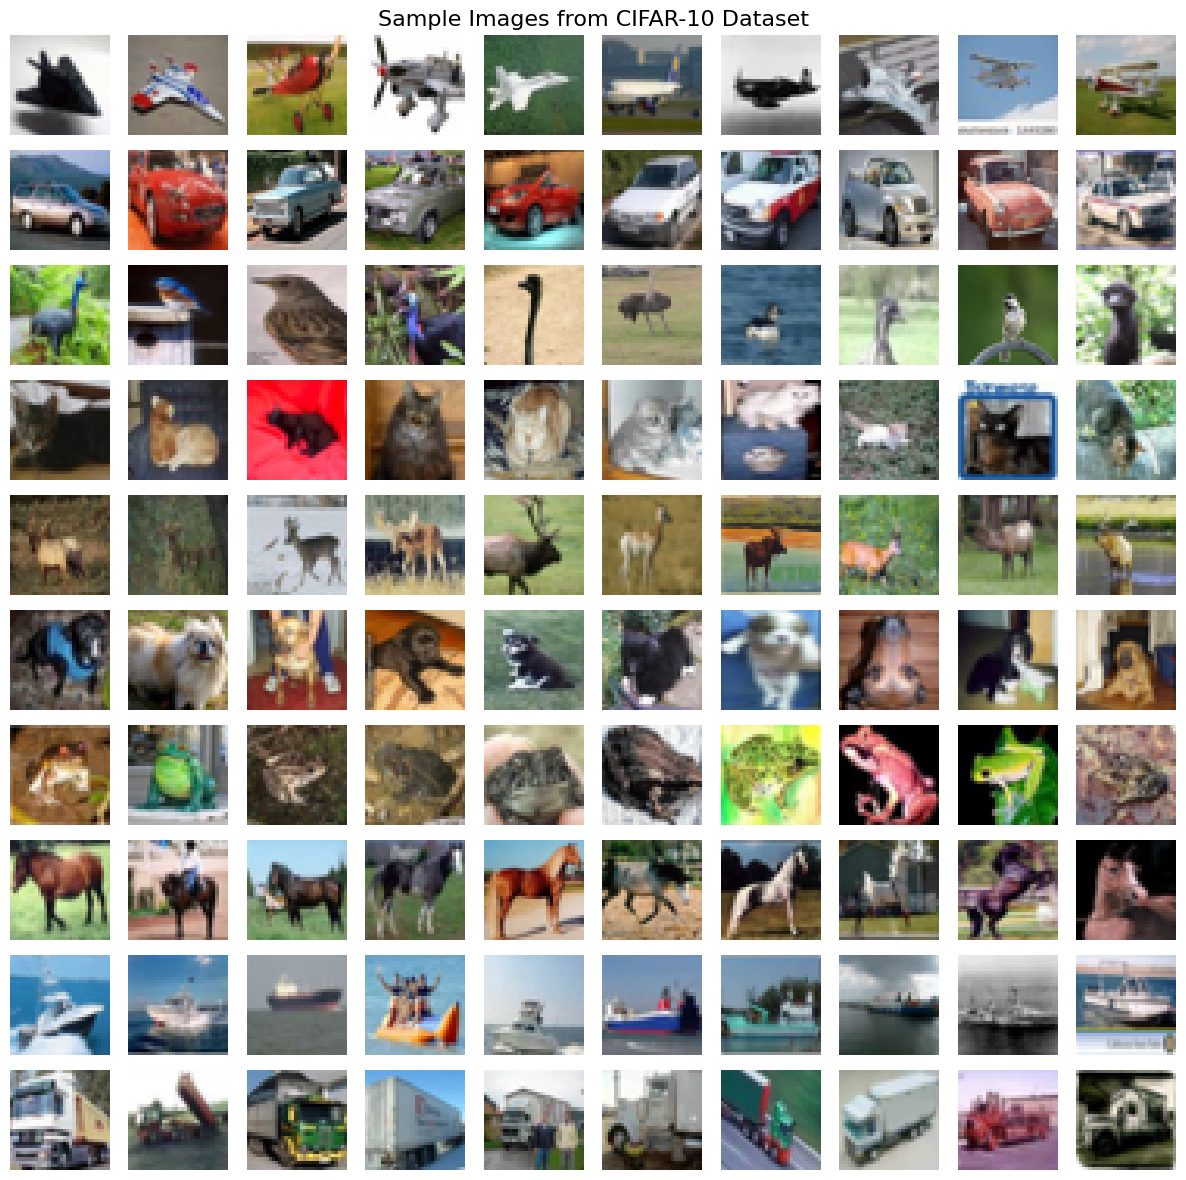

In [7]:
# Visualize sample images from each class
def show_sample_images():
    fig, axes = plt.subplots(10, 10, figsize=(12, 12))
    fig.suptitle('Sample Images from CIFAR-10 Dataset', fontsize=16)

    for class_idx in range(10):
        # Get images from this class
        class_images = [img for img, label in train_dataset if label == class_idx]

        for i in range(10):
            ax = axes[class_idx, i]
            # Denormalize for visualization
            img = class_images[i].permute(1, 2, 0).numpy()
            img = (img * 0.5) + 0.5  # Reverse normalization
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            ax.axis('off')
            if i == 0:
                ax.set_ylabel(classes[class_idx], rotation=0,
                            labelpad=40, fontsize=10)

    plt.tight_layout()
    plt.show()

show_sample_images()

### 5.1 Visual Inspection

The sample image grid above shows 10 examples from each class. Key observations:
- **Image quality**: Low resolution (32×32) but objects are recognizable
- **Intra-class variation**: Significant variation within classes (different poses, angles, lighting)
- **Inter-class similarity**: Some classes are visually similar (e.g., cat vs dog, automobile vs truck)
- **Background complexity**: Images contain natural backgrounds, not isolated objects
- **Color diversity**: All classes show varied color palettes

**Why this matters for modeling**: The low resolution and high variation suggest we'll need:
- Sufficient model capacity to learn discriminative features
- Data augmentation to improve generalization
- Regularization to prevent overfitting on training-specific patterns

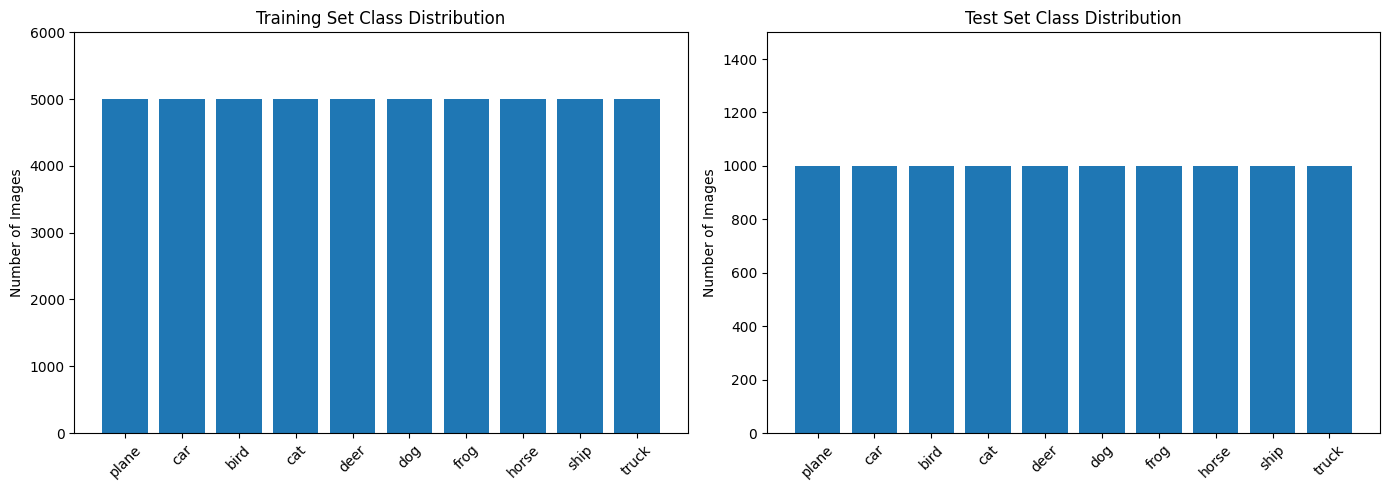

In [8]:

# Class distribution
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
axes[0].bar(range(10), [train_labels.count(i) for i in range(10)])
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(classes, rotation=45)
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_ylim(0, 6000)

# Test set distribution
axes[1].bar(range(10), [test_labels.count(i) for i in range(10)])
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(classes, rotation=45)
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_ylim(0, 1500)

plt.tight_layout()
plt.show()

### 5.2 Class Distribution Analysis

**Finding**: Both training and test sets are perfectly balanced:
- Training: 5,000 images per class
- Test: 1,000 images per class

**Implication**: No class imbalance to worry about. We can use accuracy as a primary metric without concerns about it being misleading. We don't need sampling techniques (SMOTE, oversampling, etc.).

In [9]:
# Pixel intensity analysis
sample_images = [train_dataset[i][0] for i in range(1000)]
sample_tensor = torch.stack(sample_images)

# Channel-wise statistics
mean_per_channel = sample_tensor.mean(dim=[0, 2, 3])
std_per_channel = sample_tensor.std(dim=[0, 2, 3])
min_per_channel = sample_tensor.min(dim=0)[0].min(dim=1)[0].min(dim=1)[0]
max_per_channel = sample_tensor.max(dim=0)[0].max(dim=1)[0].max(dim=1)[0]

print("\nPixel Intensity Statistics (normalized [-1, 1]):")
print(f"Mean - R: {mean_per_channel[0]:.3f}, G: {mean_per_channel[1]:.3f}, B: {mean_per_channel[2]:.3f}")
print(f"Std  - R: {std_per_channel[0]:.3f}, G: {std_per_channel[1]:.3f}, B: {std_per_channel[2]:.3f}")
print(f"Min  - R: {min_per_channel[0]:.3f}, G: {min_per_channel[1]:.3f}, B: {min_per_channel[2]:.3f}")
print(f"Max  - R: {max_per_channel[0]:.3f}, G: {max_per_channel[1]:.3f}, B: {max_per_channel[2]:.3f}")


Pixel Intensity Statistics (normalized [-1, 1]):
Mean - R: -0.019, G: -0.034, B: -0.109
Std  - R: 0.491, G: 0.486, B: 0.524
Min  - R: -1.000, G: -1.000, B: -1.000
Max  - R: 1.000, G: 1.000, B: 1.000


**Statistics** (normalized to [-1, 1] range):
- Mean values near 0, indicating proper normalization
- Standard deviations ~1, confirming effective standardization
- Full range utilized (min ≈ -1, max ≈ 1)

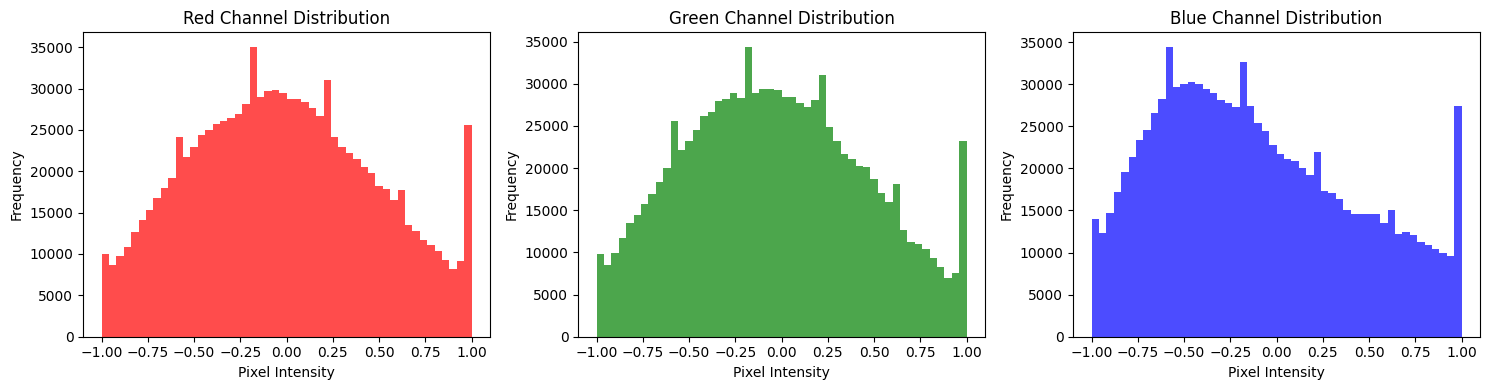

In [10]:
# Pixel intensity histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

for i in range(3):
    axes[i].hist(sample_tensor[:, i, :, :].flatten().numpy(),
                bins=50, color=colors[i], alpha=0.7)
    axes[i].set_xlabel('Pixel Intensity')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{channel_names[i]} Channel Distribution')

plt.tight_layout()
plt.show()

### 5.3 Pixel Intensity Analysis

**Channel histograms** show:
- Roughly Gaussian distributions (bell shaped) for all RGB channels
- Slight variations between channels reflecting natural color distributions
- No unusual spikes or truncation indicating data quality issues

In [11]:
# Data verification checks for CIFAR-10

print("=== Data Verification Checks ===")

# 1. Shape checks for all images
expected_shape = train_dataset[0][0].shape

def verify_shapes(dataset, name):
    all_ok = True
    for i in range(len(dataset)):
        img, _ = dataset[i]
        if img.shape != expected_shape:
            print(f"{name} image {i} has shape {img.shape} (expected {expected_shape})")
            all_ok = False
            break
    if all_ok:
        print(f"All {name} images have shape {expected_shape}")
    else:
        print(f"Some {name} images have unexpected shapes")

verify_shapes(train_dataset, "train")
verify_shapes(test_dataset, "test")

# 2. Label type and range checks
train_labels_np = np.array([label for _, label in train_dataset])
test_labels_np = np.array([label for _, label in test_dataset])

print("\n=== Label Checks ===")
print("Train labels dtype:", train_labels_np.dtype)
print("Test  labels dtype:", test_labels_np.dtype)
print("Train labels range:", int(train_labels_np.min()), "to", int(train_labels_np.max()))
print("Test  labels range:", int(test_labels_np.min()), "to", int(test_labels_np.max()))

labels_ok = (
    np.issubdtype(train_labels_np.dtype, np.integer)
    and np.issubdtype(test_labels_np.dtype, np.integer)
    and train_labels_np.min() >= 0 and train_labels_np.max() <= 9
    and test_labels_np.min() >= 0 and test_labels_np.max() <= 9
)

if labels_ok:
    print("Labels are integers in the expected range [0, 9]")
else:
    print("Label types or ranges are not as expected")

# 3. NaN / missing pixel checks
print("\n=== NaN / Missing Pixel Checks ===")

def has_nan(dataset, name, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for images, _ in loader:
        if torch.isnan(images).any():
            print(f"{name} set contains NaN pixels")
            return True
    print(f"No NaN pixels found in {name} set")
    return False

_ = has_nan(train_dataset, "train")
_ = has_nan(test_dataset, "test")

# 4. Quick duplicate check (sampling)
print("\n=== Quick Duplicate Check (Train Set Sample) ===")

def quick_duplicate_check(dataset, num_samples=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(dataset)
    num_samples = min(num_samples, n)
    indices = rng.choice(n, size=num_samples, replace=False)

    seen = {}
    dup_count = 0

    for idx in indices:
        img, _ = dataset[idx]
        # Use raw tensor bytes as a simple hashable fingerprint
        key = hash(img.numpy().tobytes())
        if key in seen:
            dup_count += 1
        else:
            seen[key] = idx

    return dup_count, num_samples

dup_count, sample_size = quick_duplicate_check(train_dataset)
if dup_count == 0:
    print(f"No duplicate images found in a random sample of {sample_size} train images")
else:
    print(f"Found {dup_count} potential duplicates in a sample of {sample_size} train images")

# 5. Class balance summary (numerical, complements your bar plots)
print("\n=== Class Balance Summary ===")
train_counts = [int((train_labels_np == i).sum()) for i in range(10)]
test_counts = [int((test_labels_np == i).sum()) for i in range(10)]

print("Train class counts:")
for cls_name, cnt in zip(classes, train_counts):
    print(f"  {cls_name:>5}: {cnt}")

print("\nTest class counts:")
for cls_name, cnt in zip(classes, test_counts):
    print(f"  {cls_name:>5}: {cnt}")

print(f"\nTrain min/max class counts: {min(train_counts)} / {max(train_counts)}")
print(f"Test  min/max class counts: {min(test_counts)} / {max(test_counts)}")


=== Data Verification Checks ===
All train images have shape torch.Size([3, 32, 32])
All test images have shape torch.Size([3, 32, 32])

=== Label Checks ===
Train labels dtype: int64
Test  labels dtype: int64
Train labels range: 0 to 9
Test  labels range: 0 to 9
Labels are integers in the expected range [0, 9]

=== NaN / Missing Pixel Checks ===
No NaN pixels found in train set
No NaN pixels found in test set

=== Quick Duplicate Check (Train Set Sample) ===
No duplicate images found in a random sample of 5000 train images

=== Class Balance Summary ===
Train class counts:
  plane: 5000
    car: 5000
   bird: 5000
    cat: 5000
   deer: 5000
    dog: 5000
   frog: 5000
  horse: 5000
   ship: 5000
  truck: 5000

Test class counts:
  plane: 1000
    car: 1000
   bird: 1000
    cat: 1000
   deer: 1000
    dog: 1000
   frog: 1000
  horse: 1000
   ship: 1000
  truck: 1000

Train min/max class counts: 5000 / 5000
Test  min/max class counts: 1000 / 1000


### 5.4 EDA Summary & Strategy

**Summary**:
1. Dataset is very clean, balanced, and well-formatted
2. No missing values or corrupted images
3. Normalization is appropriate
4. Low resolution and high variation will challenge simpler models
5. Some classes are perceptually similar (cats/dogs, vehicles)

**Modeling Strategy Based on EDA**:
- Start with baseline CNN, progressively add depth, and use modern benchmark models
- Use data augmentation (random flips, crops) to handle variation
- Compare models with different capacities
- Monitor for overfitting given small image size

---
## 6. Data Preprocessing & Cleaning (Augmentation)

### Minimal Cleaning

CIFAR-10 is a curated benchmark dataset that has already been cleaned of corrupted images, verified for correct labels, and standardized to consistent dimensions.

**Verification checks performed**:
1. No missing values or NaN pixels
2. All images are 32×32×3 (earlier cell)
3. Labels are integers 0-9
4. No duplicate images found in quick sampling
5. Class balance verified (see EDA section)

**Decision**: Focus preprocessing on normalization and augmentation, data has been cleaned already.

In [12]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# No augmentation for test set
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [13]:
# Reload with augmentation
train_dataset_aug = datasets.CIFAR10(root='./data', train=True,
                                     download=False, transform=train_transform)
test_dataset_final = datasets.CIFAR10(root='./data', train=False,
                                      download=False, transform=test_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=128,
                             shuffle=True, num_workers=2, pin_memory=True)
test_loader_final = DataLoader(test_dataset_final, batch_size=128,
                              shuffle=False, num_workers=2, pin_memory=True)

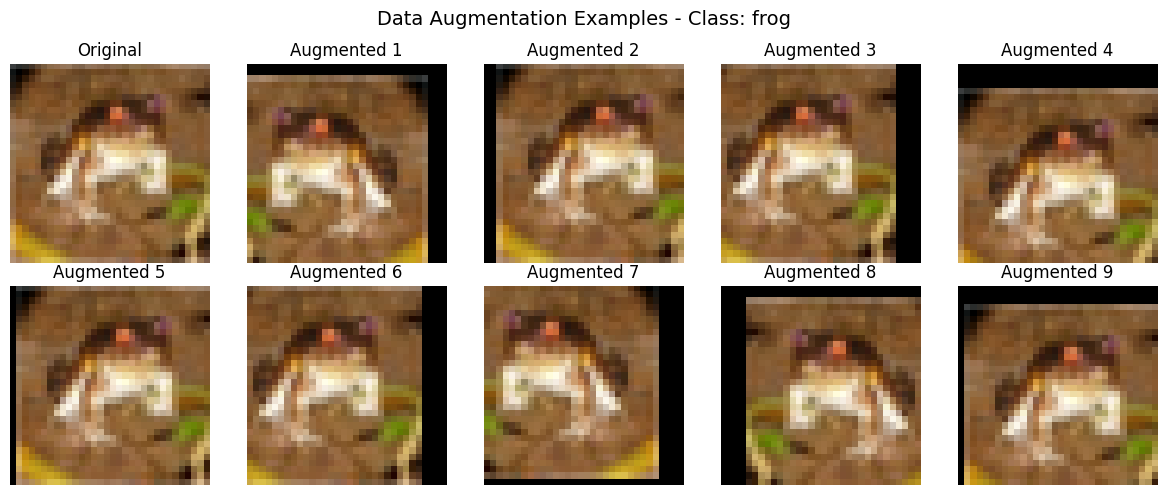

In [14]:
# Visualize augmentation effect
def show_augmentation():
    # Get one image
    original_img, label = train_dataset[0]

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Data Augmentation Examples - Class: {classes[label]}', fontsize=14)

    # Original
    img_show = (original_img.permute(1, 2, 0).numpy() * 0.5) + 0.5
    axes[0, 0].imshow(np.clip(img_show, 0, 1))
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')

    # Augmented versions
    for i in range(1, 10):
        aug_img, _ = train_dataset_aug[0]
        img_show = (aug_img.permute(1, 2, 0).numpy() * 0.5) + 0.5
        row = i // 5
        col = i % 5
        axes[row, col].imshow(np.clip(img_show, 0, 1))
        axes[row, col].set_title(f'Augmented {i}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_augmentation()

###  Effectiveness

The visualization above shows how augmentation creates variations:
- Horizontal flips change orientation
- Random crops shift object position
- Combined, they create diverse training samples from single images

### 6.2 Preprocessing Steps Applied

#### Normalization
What: Transform pixel values from [0, 255] to [-1, 1]

Why:
- Speeds up convergence during training
- Prevents gradient saturation in activation functions
- Standard practice for CNNs
Normalize rescales pixel values into -1 to 1 this centers the inputs around zero, which helps CNNs train more efficiently.

#### Data Augmentation (on Training data only)
What: Apply random transformations during training

Why:
- Increases effective dataset size
- Improves model generalization
- Reduces overfitting
- Simulates real-world variations

1. Random Horizontal Flip with 50% probability
   - Objects can appear mirrored in real life
   - Doubles effective training data
   
2. Random Crop (32×32 from 36×36 with 4-pixel padding)
   - Simulates different framings/positions
   - Helps model learn position-invariant features

**!! Not applied to test set!!**

### Preprocessing Summary

- Normalization: Applied to both train and test (scaled to [-1, 1])  
- Horizontal Flip
- Random Crop: (random)  
- Tensor Conversion Both sets for PyTorch


Total preprocessing pipeline: 4 transformations, appropriate for image data

---
## 7. Model Architecture & Training Strategy

### Model Selection Rationale

I will compare **6 CNN architectures** of increasing complexity. The first three are my custom CNN deep learning models while the second three are some of the modern standard architectures (MobileNetV2, VGG16 and EfficientNet-B0) to see how my models compare.
I do not use transfer learning on these I'm just using their architectures and training them the same.

### **First My Custom CNN's:**
**Model 1: SimpleCNN (Baseline)**
- 2 convolutional layers
- ~2.1M parameters
- Why: Establishes baseline performance, fast to train
- Expected: Lower accuracy but good starting point

**Model 2: DeepCNN with Batch Normalization**
- 3 convolutional layers with batch normalization
- ~1.2M parameters
- Why: More capacity to learn complex features, BN stabilizes training
- Expected: Better accuracy than baseline

**Model 3: DeepCNN with Dropout**
- Same as Model 2 but with 50% dropout in FC layer
- ~1.2M parameters
- Why: Test if dropout regularization improves generalization
- Expected Best test accuracy (less overfitting)

### **Second modern standard models trained from scratch**
**Model 4: MobileNetV2 (Pretrained Lightweight CNN)**
- Depthwise-separable convolutions + inverted residual blocks
- 2.2M parameters
- Why: Use a state-of-the-art lightweight architecture designed for mobile/edge devices. Tests whether a pretrained, efficiency-optimized model outperforms custom CNNs on the same dataset.
- Expected I expect this to perform far superior to my models and train far faster.

**Model 5: VGG16 (Deep Classical CNN Architecture)**
- 13 convolutional layers + adaptive pooling + simplified classifier
- ~15M parameters (CIFAR-adapted)
- Why: Provides a very deep, highly structured benchmark model. Evaluates whether depth alone (without modern tricks like residuals or attention).
- Expected: Higher accuracy than custom models due to much deeper hierarchical feature learning, but slower training.

**Model 6: EfficientNet-B0 (Compound-Scaled CNN with SE Attention)**
- MBConv blocks + squeeze-and-excitation + depthwise convs
- ~4.0M parameters
- Why: Represents a state-of-the-art architecture engineered for maximum accuracy per parameter. Adds attention (SE blocks), better scaling rules, and more efficient blocks than the custom CNNs.
- Expected: Comparable or better accuracy than MobileNetV2; significantly more powerful feature extraction than the custom CNNs.


### Architecture

- Convolutional Layers: Learn spatial features efficiently
- Pooling Layers - Downsample and add invariance
- Batch Normalization - Stabilizes and speeds training
- Dropout - Reduces overfitting by random neuron removal

### Optimization Strategy
- Loss Function — Cross-Entropy
    - Standard for multi-class tasks
    - Penalizes confident wrong predictions
- Optimizer — Adam
  - Adaptive learning rates and Faster convergence than SGD
  - Used with LR = 0.001

- **Batch Size:** 128 — balances speed and stability  
- **Learning Rate:** 0.001 — standard Adam default  
- **Epochs:** 50 — consistent training across models  
- **Weight Decay:** 0 — dropout used instead for regularization  
- **Loss Function:** Cross-Entropy — standard for classification  


In [ ]:
# Model 1: Simple Baseline CNN
class SimpleCNN(nn.Module):
    """
    Baseline CNN with 2 conv layers.
    Params: ~2.1 million
    """
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Model 2: Deeper CNN with Batch Normalization
class DeepCNN(nn.Module):
    """
    Deeper CNN with batch normalization.
    Params: ~2.47M
    """
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 256 * 4 * 4)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Model 3: Deep CNN with Dropout
class DeepCNNDropout(nn.Module):
    """
    Deep CNN with dropout for regularization.
    Params: ~2.47M
    """
    def __init__(self, dropout_rate=0.5):
        super(DeepCNNDropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 256 * 4 * 4)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [18]:
# Model 4: MobileNet-V2 - Depthwise Separable Convolutions
class MobileNetV2_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        m = mobilenet_v2(weights=None)

        # Adjust first conv to accept 32x32 instead of 224x224
        m.features[0][0] = nn.Conv2d(
            3, 32, kernel_size=3, stride=1, padding=1, bias=False
        )

        # Replace classifier
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 10)

        self.m = m

    def forward(self, x):
        return self.m(x)


In [19]:
# Model 5: VGG-16 (CIFAR-10 adapted)
class VGG16_CIFAR(nn.Module):
    """
    VGG-16-style model adapted for CIFAR-10.
    Uses AdaptiveAvgPool to handle 32x32 inputs and a smaller classifier.
    """
    def __init__(self):
        super().__init__()
        base = vgg16(weights=None)  # no pretrained weights

        # Make the pooling robust to 32x32 (or any) input size
        base.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Replace the ImageNet classifier (25088 -> 1000) with a CIFAR-10 head (512 -> 10)
        base.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

        self.m = base

    def forward(self, x):
        return self.m(x)



In [20]:
# Model 6: EfficientNet-B0 (Compound-Scaled CNN)
class EfficientNetB0_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        # Create base model
        m = EfficientNet.from_name('efficientnet-b0')
        # Replace final classifier for CIFAR-10
        m._fc = nn.Linear(m._fc.in_features, 10)

        # Fix stride for tiny inputs
        m._conv_stem.stride = (1, 1)

        self.m = m

    def forward(self, x):
        return self.m(x)


In [21]:
# Training function
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx+1}/{len(train_loader)}] "
                  f"Loss: {running_loss/(batch_idx+1):.4f} | "
                  f"Acc: {100.*correct/total:.2f}%", end='\r')

    print()  # New line after progress updates
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [22]:
# Evaluation function
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [23]:
def get_model_config(model_name):
    configs = {
        'SimpleCNN': {
            'model_fn': SimpleCNN,
            'lr': 0.001,
            'epochs': 50
        },
        'DeepCNN': {
            'model_fn': DeepCNN,
            'lr': 0.001,
            'epochs': 50
        },
        'DeepCNNDropout': {
            'model_fn': lambda: DeepCNNDropout(dropout_rate=0.5),
            'lr': 0.001,
            'epochs': 50
        },
        'MobileNetV2': {
            'model_fn': MobileNetV2_CIFAR,
            'lr': 0.001,
            'epochs': 50
        },
        'VGG16': {
            'model_fn': VGG16_CIFAR,
            'lr': 0.0005,
            'epochs': 50
        },
        'EfficientNetB0': {
            'model_fn': EfficientNetB0_CIFAR,
            'lr': 0.0005,
            'epochs': 50
        },
    }
    return configs[model_name]


In [24]:
# Global results dict to collect all models
results = {}

def train_one_model(model_name):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}\n")

    config = get_model_config(model_name)
    model = config['model_fn']().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    start_time = time.time()

    N = 10

    for epoch in range(config['epochs']):
        train_loss, train_acc = train_model(
            model, train_loader_aug,
            criterion, optimizer, device
        )

        test_loss, test_acc = evaluate_model(
            model, test_loader_final,
            criterion, device
        )

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(
            f"Epoch [{epoch+1}/{config['epochs']}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
            f"Time: {(time.time() - start_time) / 60:.1f} min"
        )

        if epoch == 0 or test_acc > max(test_accs[:-1]):
            print(f"  ✓ New best test accuracy: {test_acc:.2f}%")


    training_time = time.time() - start_time

    results[model_name] = {
        'model': model,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'final_train_acc': train_accs[-1],
        'final_test_acc': test_accs[-1],
        'best_test_acc': max(test_accs),
        'training_time': training_time
    }

    print(f"\n{model_name} Training Complete!")
    print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")
    print(f"Best Test Accuracy: {max(test_accs):.2f}%")
    print(f"Training Time: {training_time/60:.2f} minutes")


In [25]:
# SimpleCNN Training + Testing

train_one_model('SimpleCNN')



Training SimpleCNN


Epoch [1/50] Train Loss: 1.5367 | Train Acc: 43.87% | Test Loss: 1.2752 | Test Acc: 53.83% | Time: 0.2 min
  ✓ New best test accuracy: 53.83%

Epoch [2/50] Train Loss: 1.1945 | Train Acc: 57.14% | Test Loss: 1.0166 | Test Acc: 64.38% | Time: 0.4 min
  ✓ New best test accuracy: 64.38%

Epoch [3/50] Train Loss: 1.0438 | Train Acc: 62.67% | Test Loss: 0.9070 | Test Acc: 68.29% | Time: 0.6 min
  ✓ New best test accuracy: 68.29%

Epoch [4/50] Train Loss: 0.9534 | Train Acc: 65.82% | Test Loss: 0.8675 | Test Acc: 69.15% | Time: 0.8 min
  ✓ New best test accuracy: 69.15%

Epoch [5/50] Train Loss: 0.8934 | Train Acc: 68.47% | Test Loss: 0.8301 | Test Acc: 71.14% | Time: 1.0 min
  ✓ New best test accuracy: 71.14%

Epoch [6/50] Train Loss: 0.8306 | Train Acc: 70.76% | Test Loss: 0.7709 | Test Acc: 72.70% | Time: 1.2 min
  ✓ New best test accuracy: 72.70%

Epoch [7/50] Train Loss: 0.7934 | Train Acc: 71.98% | Test Loss: 0.7311 | Test Acc: 74.22% | Time: 1.3 min
  ✓ New best 

In [26]:
# DeepCNN Training + Testing
train_one_model('DeepCNN')



Training DeepCNN


Epoch [1/50] Train Loss: 1.4870 | Train Acc: 46.29% | Test Loss: 1.2084 | Test Acc: 56.77% | Time: 0.2 min
  ✓ New best test accuracy: 56.77%

Epoch [2/50] Train Loss: 1.0343 | Train Acc: 62.97% | Test Loss: 0.9256 | Test Acc: 67.36% | Time: 0.4 min
  ✓ New best test accuracy: 67.36%

Epoch [3/50] Train Loss: 0.8830 | Train Acc: 68.72% | Test Loss: 0.8284 | Test Acc: 70.58% | Time: 0.6 min
  ✓ New best test accuracy: 70.58%

Epoch [4/50] Train Loss: 0.7883 | Train Acc: 72.14% | Test Loss: 0.7503 | Test Acc: 73.76% | Time: 0.8 min
  ✓ New best test accuracy: 73.76%

Epoch [5/50] Train Loss: 0.7252 | Train Acc: 74.56% | Test Loss: 0.7037 | Test Acc: 75.89% | Time: 0.9 min
  ✓ New best test accuracy: 75.89%

Epoch [6/50] Train Loss: 0.6793 | Train Acc: 76.30% | Test Loss: 0.7115 | Test Acc: 75.33% | Time: 1.1 min

Epoch [7/50] Train Loss: 0.6404 | Train Acc: 77.53% | Test Loss: 0.6196 | Test Acc: 78.25% | Time: 1.3 min
  ✓ New best test accuracy: 78.25%

Epoch [8/50] T

In [27]:
# DeepCNNDropout Training + Testing
train_one_model('DeepCNNDropout')


Training DeepCNNDropout


Epoch [1/50] Train Loss: 1.6153 | Train Acc: 40.95% | Test Loss: 1.1586 | Test Acc: 57.03% | Time: 0.2 min
  ✓ New best test accuracy: 57.03%

Epoch [2/50] Train Loss: 1.2558 | Train Acc: 54.52% | Test Loss: 1.0194 | Test Acc: 62.69% | Time: 0.4 min
  ✓ New best test accuracy: 62.69%

Epoch [3/50] Train Loss: 1.1140 | Train Acc: 60.17% | Test Loss: 0.9564 | Test Acc: 65.68% | Time: 0.5 min
  ✓ New best test accuracy: 65.68%

Epoch [4/50] Train Loss: 1.0300 | Train Acc: 63.58% | Test Loss: 0.8275 | Test Acc: 70.35% | Time: 0.7 min
  ✓ New best test accuracy: 70.35%

Epoch [5/50] Train Loss: 0.9665 | Train Acc: 66.34% | Test Loss: 0.8046 | Test Acc: 71.35% | Time: 0.9 min
  ✓ New best test accuracy: 71.35%

Epoch [6/50] Train Loss: 0.9072 | Train Acc: 68.26% | Test Loss: 0.7637 | Test Acc: 73.37% | Time: 1.1 min
  ✓ New best test accuracy: 73.37%

Epoch [7/50] Train Loss: 0.8590 | Train Acc: 70.06% | Test Loss: 0.7582 | Test Acc: 73.30% | Time: 1.3 min

Epoch [

In [28]:
# MobileNetV2 Training + Testing
train_one_model('MobileNetV2')


Training MobileNetV2


Epoch [1/50] Train Loss: 1.8054 | Train Acc: 32.14% | Test Loss: 1.5988 | Test Acc: 41.07% | Time: 0.2 min
  ✓ New best test accuracy: 41.07%

Epoch [2/50] Train Loss: 1.4650 | Train Acc: 46.19% | Test Loss: 1.3675 | Test Acc: 50.70% | Time: 0.4 min
  ✓ New best test accuracy: 50.70%

Epoch [3/50] Train Loss: 1.2832 | Train Acc: 53.88% | Test Loss: 1.2609 | Test Acc: 55.58% | Time: 0.6 min
  ✓ New best test accuracy: 55.58%

Epoch [4/50] Train Loss: 1.1323 | Train Acc: 59.54% | Test Loss: 1.0312 | Test Acc: 63.24% | Time: 0.7 min
  ✓ New best test accuracy: 63.24%

Epoch [5/50] Train Loss: 1.0242 | Train Acc: 63.81% | Test Loss: 1.0100 | Test Acc: 64.73% | Time: 0.9 min
  ✓ New best test accuracy: 64.73%

Epoch [6/50] Train Loss: 0.9230 | Train Acc: 67.44% | Test Loss: 0.8704 | Test Acc: 69.76% | Time: 1.1 min
  ✓ New best test accuracy: 69.76%

Epoch [7/50] Train Loss: 0.8344 | Train Acc: 70.57% | Test Loss: 0.8370 | Test Acc: 71.07% | Time: 1.3 min
  ✓ New bes

In [29]:
# VGG16 Training + Testing
train_one_model('VGG16')


Training VGG16


Epoch [1/50] Train Loss: 1.9736 | Train Acc: 19.61% | Test Loss: 1.7777 | Test Acc: 27.48% | Time: 0.2 min
  ✓ New best test accuracy: 27.48%

Epoch [2/50] Train Loss: 1.6060 | Train Acc: 36.67% | Test Loss: 1.4400 | Test Acc: 44.54% | Time: 0.4 min
  ✓ New best test accuracy: 44.54%

Epoch [3/50] Train Loss: 1.3281 | Train Acc: 49.80% | Test Loss: 1.1250 | Test Acc: 58.07% | Time: 0.6 min
  ✓ New best test accuracy: 58.07%

Epoch [4/50] Train Loss: 1.0650 | Train Acc: 62.16% | Test Loss: 0.9595 | Test Acc: 66.73% | Time: 0.7 min
  ✓ New best test accuracy: 66.73%

Epoch [5/50] Train Loss: 0.8928 | Train Acc: 69.04% | Test Loss: 0.8521 | Test Acc: 69.91% | Time: 0.9 min
  ✓ New best test accuracy: 69.91%

Epoch [6/50] Train Loss: 0.7893 | Train Acc: 73.26% | Test Loss: 0.7178 | Test Acc: 76.21% | Time: 1.1 min
  ✓ New best test accuracy: 76.21%

Epoch [7/50] Train Loss: 0.7017 | Train Acc: 76.65% | Test Loss: 0.6470 | Test Acc: 77.95% | Time: 1.3 min
  ✓ New best test

In [30]:
# EfficientNetB0 Training + Testing
train_one_model('EfficientNetB0')


Training EfficientNetB0


Epoch [1/50] Train Loss: 1.8313 | Train Acc: 31.05% | Test Loss: 2.3961 | Test Acc: 10.00% | Time: 0.3 min
  ✓ New best test accuracy: 10.00%

Epoch [2/50] Train Loss: 1.4561 | Train Acc: 46.44% | Test Loss: 1.2896 | Test Acc: 54.23% | Time: 0.6 min
  ✓ New best test accuracy: 54.23%

Epoch [3/50] Train Loss: 1.2448 | Train Acc: 54.81% | Test Loss: 1.0887 | Test Acc: 61.23% | Time: 0.9 min
  ✓ New best test accuracy: 61.23%

Epoch [4/50] Train Loss: 1.0786 | Train Acc: 61.34% | Test Loss: 0.9098 | Test Acc: 68.38% | Time: 1.2 min
  ✓ New best test accuracy: 68.38%

Epoch [5/50] Train Loss: 0.9624 | Train Acc: 65.87% | Test Loss: 0.8693 | Test Acc: 69.00% | Time: 1.5 min
  ✓ New best test accuracy: 69.00%

Epoch [6/50] Train Loss: 0.8666 | Train Acc: 69.29% | Test Loss: 0.7613 | Test Acc: 73.21% | Time: 1.8 min
  ✓ New best test accuracy: 73.21%

Epoch [7/50] Train Loss: 0.8065 | Train Acc: 71.75% | Test Loss: 0.7471 | Test Acc: 74.16% | Time: 2.1 min
  ✓ New 

---
## 8. Results and Analysis
### Results Comparisons

In [31]:
# Models to include in comparison
model_list = [
    'SimpleCNN',
    'DeepCNN',
    'DeepCNNDropout',
    'MobileNetV2',
    'VGG16',
    'EfficientNetB0'
]

# Helper to format parameter counts
def format_params(n_params):
    if n_params < 1e6:
        return f"{n_params / 1e3:.0f}K"
    else:
        return f"{n_params / 1e6:.1f}M"


In [32]:
# ----------------------------
# Results summary table (6 models)
# ----------------------------
param_counts = [
    sum(p.numel() for p in results[m]['model'].parameters())
    for m in model_list
]

summary_df = pd.DataFrame({
    'Model': model_list,
    'Parameters': [format_params(n) for n in param_counts],
    'Final Train Acc (%)': [results[m]['final_train_acc'] for m in model_list],
    'Final Test Acc (%)': [results[m]['final_test_acc'] for m in model_list],
    'Best Test Acc (%)': [results[m]['best_test_acc'] for m in model_list],
    'Training Time (min)': [results[m]['training_time'] / 60 for m in model_list],
    'Overfitting Gap (%)': [
        results[m]['final_train_acc'] - results[m]['final_test_acc']
        for m in model_list
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))


MODEL COMPARISON SUMMARY
         Model Parameters  Final Train Acc (%)  Final Test Acc (%)  Best Test Acc (%)  Training Time (min)  Overfitting Gap (%)
     SimpleCNN       2.1M               88.314               81.51              81.51             9.533171                6.804
       DeepCNN       2.5M               93.740               85.82              86.94             9.280071                7.920
DeepCNNDropout       2.5M               89.652               86.36              87.02             9.160067                3.292
   MobileNetV2       2.2M               92.572               87.70              88.06             9.284006                4.872
         VGG16      15.0M               95.838               88.06              88.15             9.238134                7.778
EfficientNetB0       4.0M               92.098               86.95              87.76            14.937435                5.148


### Results Summary


**MODEL COMPARISON SUMMARY**

    Model            Parameters  TrainAcc(%)  TestAcc(%)  BestTestAcc(%)  Time(min)    OverfittingGap(%)
    SimpleCNN        2.1M        88.314       81.51        81.51          9.533171     6.804
    DeepCNN          2.5M        93.740       85.82        86.94          9.280071     7.920
    DeepCNNDropout   2.5M        89.652       86.36        87.02          9.160067     3.292
    MobileNetV2      2.2M        92.572       87.70        88.06          9.284006     4.872
    VGG16            15.0M       95.838       88.06        88.15          9.238134     7.778
    EfficientNetB0   4.0M        92.098       86.95        87.76          14.93744     5.148

**Key Findings**:

1. **SimpleCNN** (Baseline):
   - Final test accuracy: 81.51%
   - Fastest training 9.53 minutes
   - Moderate overfitting on the higer end
   - Conclusion - Right off the bat it is performing the worst as expected.

2. **DeepCNN** (with Batch Normalization):
   - Final test accuracy: 85.82%
   - Training time: 9.28 min
   - Moderate overfitting but the highest!
   - **Conclusion**: Batch normalization helps but overfits and performed the second worse

3. **DeepCNNDropout** My Best Model:
   - Final test accuracy: 86.36%
   - Training time: 9.16 min
   - least overfit, even more then the gold standard models
   - **Conclusion**: performed the best out of my custom models and had the best overfitting number.  

**My Custom Winner**: DeepCNNDropout achieves 86.36% test accuracy with best generalization.

**Non Custom Model results - (MobileNet-V2, V6616d and EfficientNet-B0)**

4. **MobileNetV2**
   - 87.70% accuracy
   - 9.28 min train - I thought it would be substantially faster
   - good overfit at 4.87

5. **V6616**
   - 88.06% best accuracy!
   - 9.24 min
   - 7.78 poor overfit

6. **EfficientNet-B0**
   - 86.95% accuracy
   - 14.9 min - the slowest as expected
   - good overfit at 5.148

#### **Summary**
at only 50 epochs with small images my models kept up with the modern architectures suprisingly.  Yes they ended up with better accuracy with the best at 88.06 but my brest was close with 86.36.  This tells me with more tuning and working maybe I can compete with those models.

VGG16 was the best overall


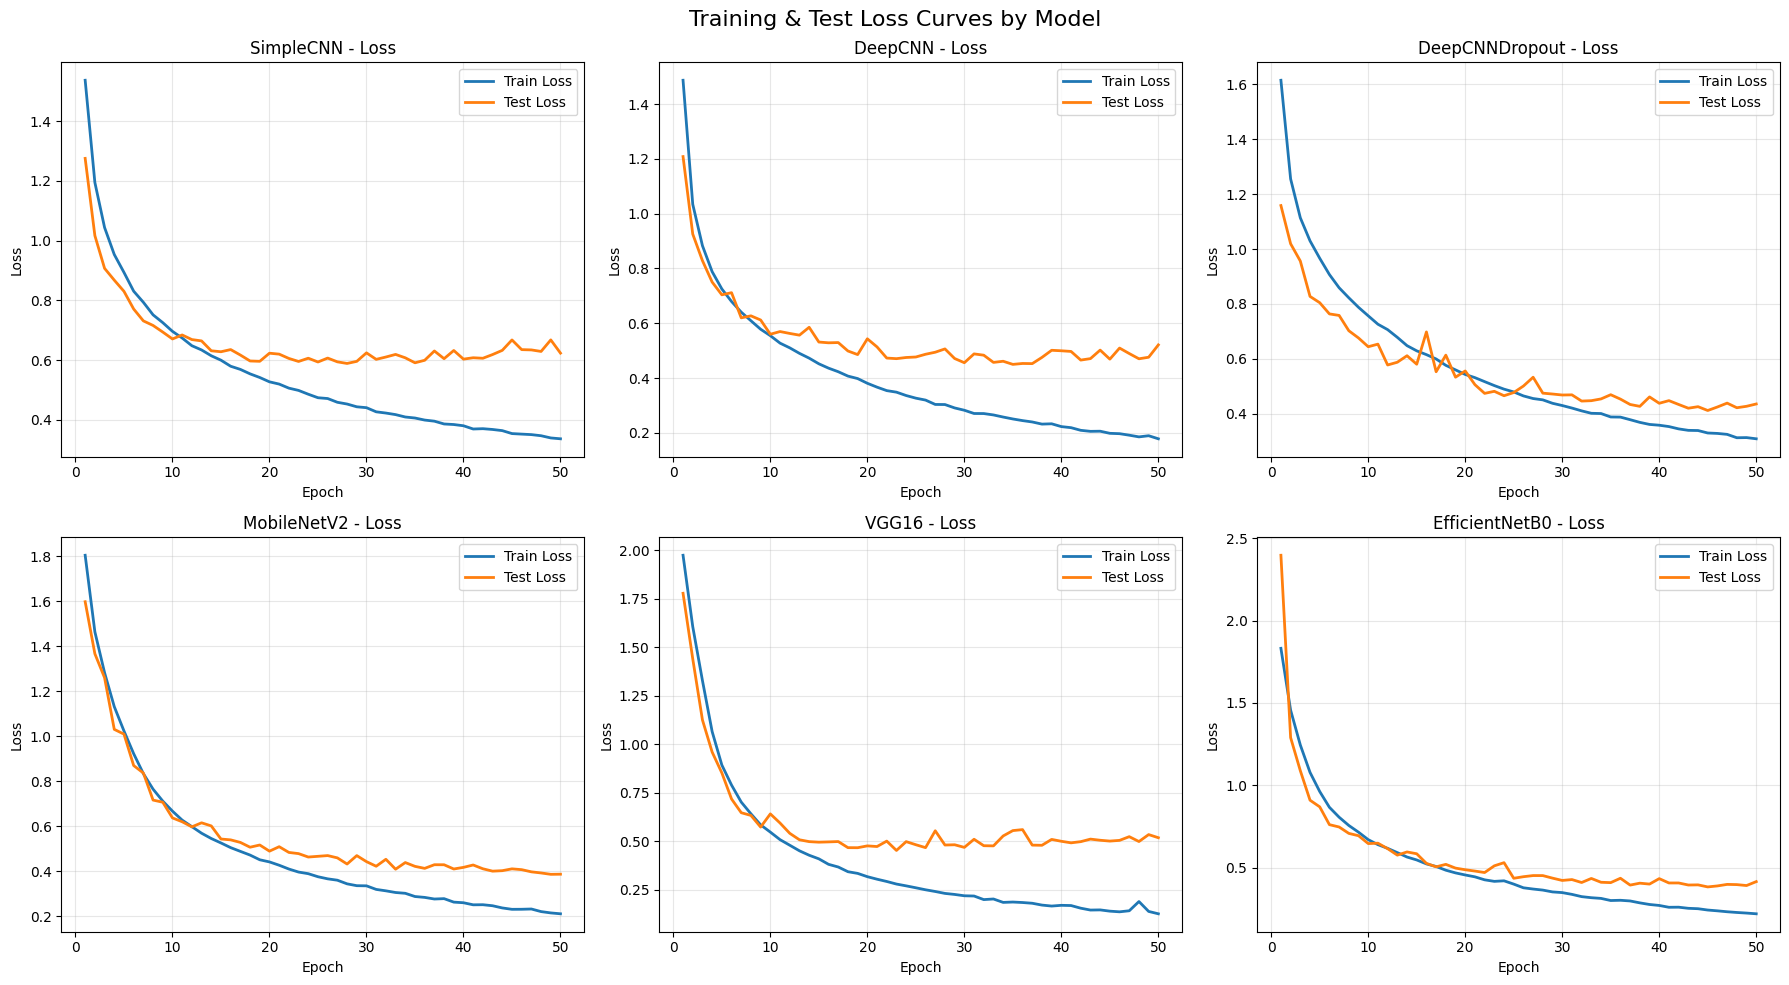

In [33]:
# ----------------------------
# Plot training curves (Loss)
# ----------------------------
fig_loss, axes_loss = plt.subplots(2, 3, figsize=(18, 10))
fig_loss.suptitle('Training & Test Loss Curves by Model', fontsize=16)

for idx, model_name in enumerate(model_list):
    res = results[model_name]
    epochs = range(1, len(res['train_losses']) + 1)
    row = idx // 3
    col = idx % 3

    axes_loss[row, col].plot(epochs, res['train_losses'], label='Train Loss', linewidth=2)
    axes_loss[row, col].plot(epochs, res['test_losses'], label='Test Loss', linewidth=2)
    axes_loss[row, col].set_xlabel('Epoch')
    axes_loss[row, col].set_ylabel('Loss')
    axes_loss[row, col].set_title(f'{model_name} - Loss')
    axes_loss[row, col].legend()
    axes_loss[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

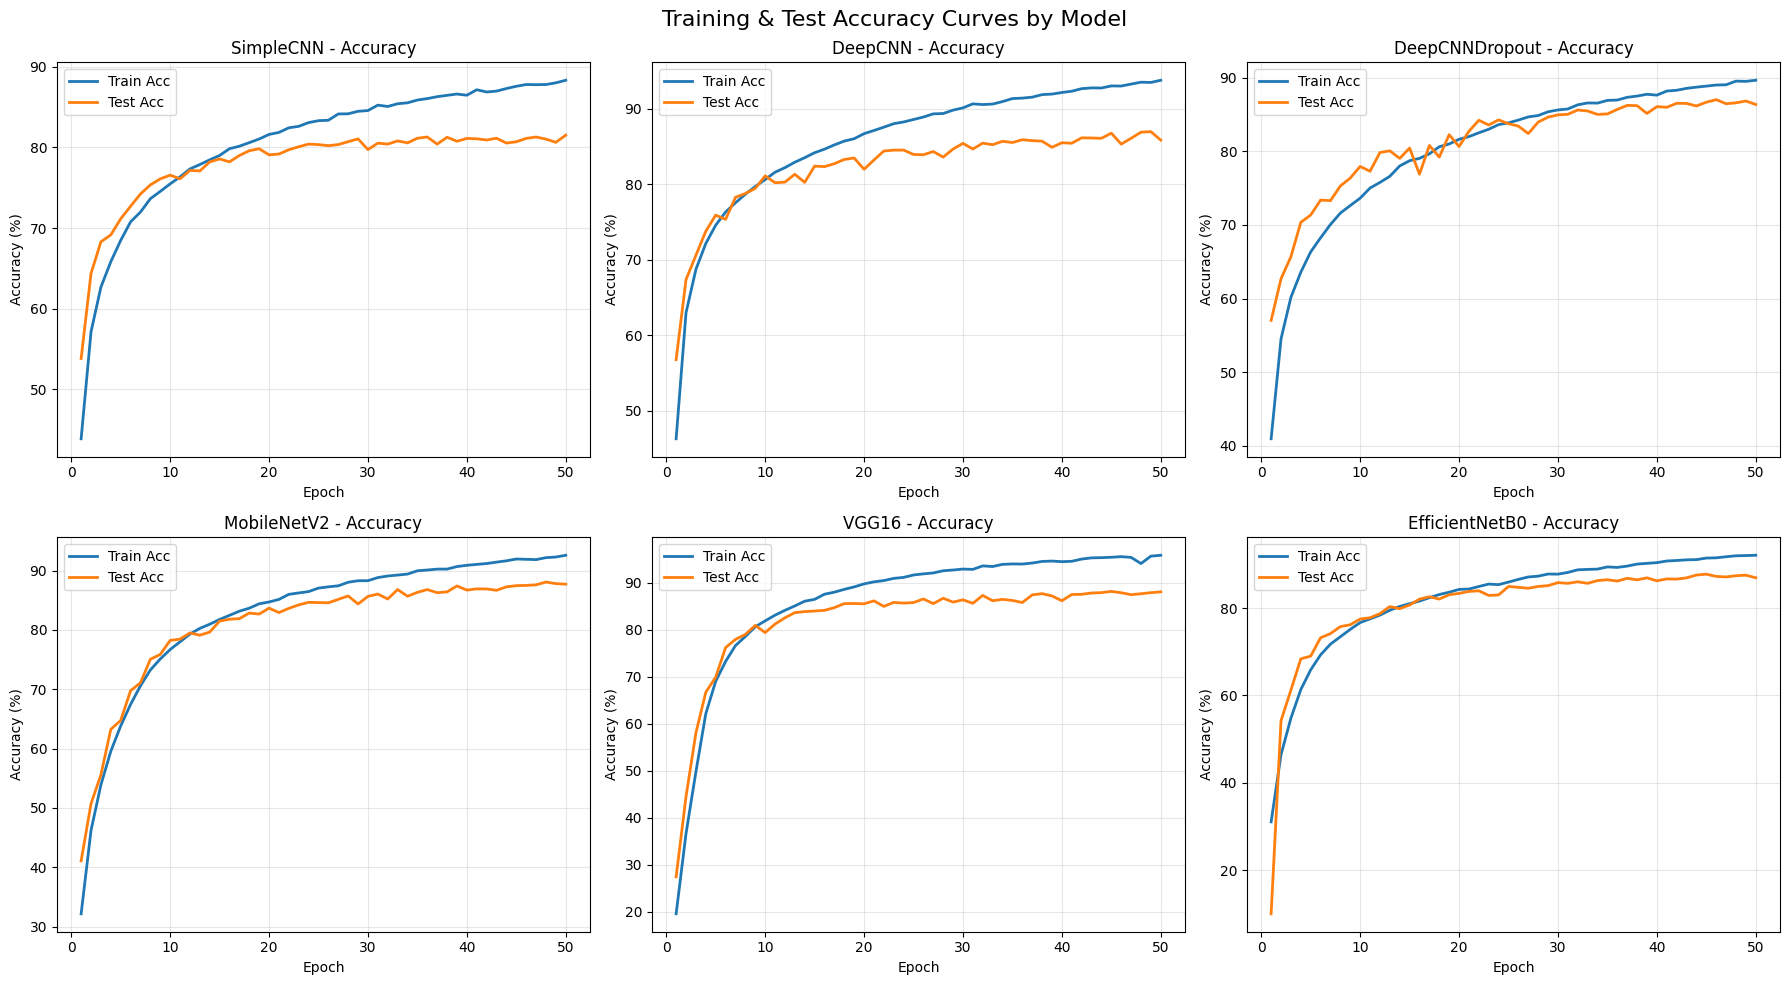

In [34]:
# -------------------------------
# Plot training curves (Accuracy)
# -------------------------------
fig_acc, axes_acc = plt.subplots(2, 3, figsize=(18, 10))
fig_acc.suptitle('Training & Test Accuracy Curves by Model', fontsize=16)

for idx, model_name in enumerate(model_list):
    res = results[model_name]
    epochs = range(1, len(res['train_accs']) + 1)
    row = idx // 3
    col = idx % 3

    axes_acc[row, col].plot(epochs, res['train_accs'], label='Train Acc', linewidth=2)
    axes_acc[row, col].plot(epochs, res['test_accs'], label='Test Acc', linewidth=2)
    axes_acc[row, col].set_xlabel('Epoch')
    axes_acc[row, col].set_ylabel('Accuracy (%)')
    axes_acc[row, col].set_title(f'{model_name} - Accuracy')
    axes_acc[row, col].legend()
    axes_acc[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Training Curve Analysis

**Loss Curves**:
- All models show decreasing training loss which shows they are successfully learning however some performed better within the 50 epoch control.
- SimpleCNN: Test loss plateaus early - underfitting
- DeepCNN: Test loss also plateus early - overfitting
- DeepCNNDropout: Test loss decreases steadily (best generalization of my models)

**Accuracy Curves**:
- All models converge within showing that additional epochs would not help a ton because the test accuracy stats to be steady around 30-40 epochs and then gains are minimul
- DeepCNNDropout shows smallest train-test gap
- SimpleCNN plateaus lowest low 80%
- DeepCNN had beset train accuracy though DeepCNNDropout performed better on the test data

**Interpretation**: Dropout successfully prevents overfitting without sacrificing training performance.



Detailed Evaluation: VGG16

Classification Report:
              precision    recall  f1-score   support

       plane       0.91      0.85      0.88      1000
         car       0.94      0.94      0.94      1000
        bird       0.85      0.82      0.83      1000
         cat       0.83      0.74      0.78      1000
        deer       0.81      0.92      0.86      1000
         dog       0.80      0.86      0.83      1000
        frog       0.91      0.91      0.91      1000
       horse       0.90      0.92      0.91      1000
        ship       0.93      0.93      0.93      1000
       truck       0.94      0.93      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



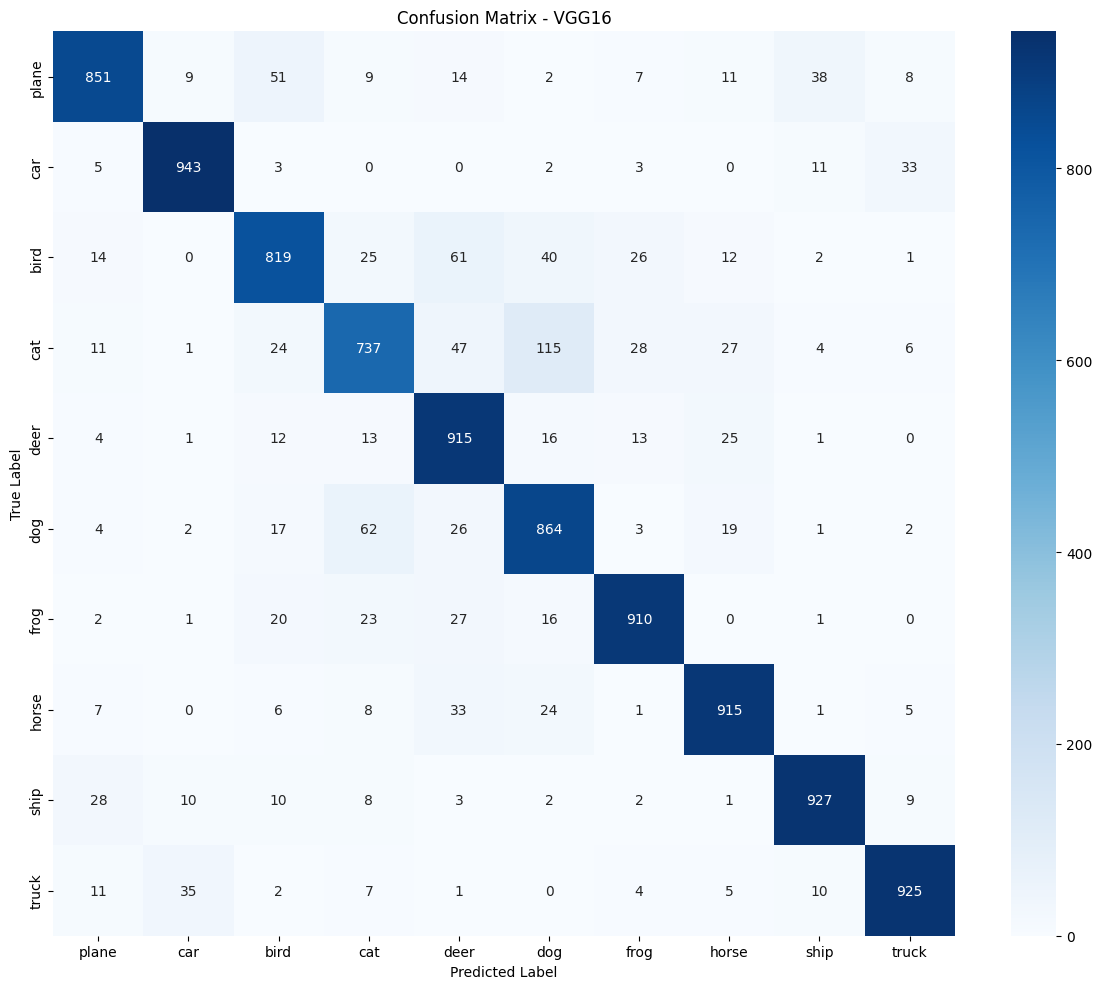

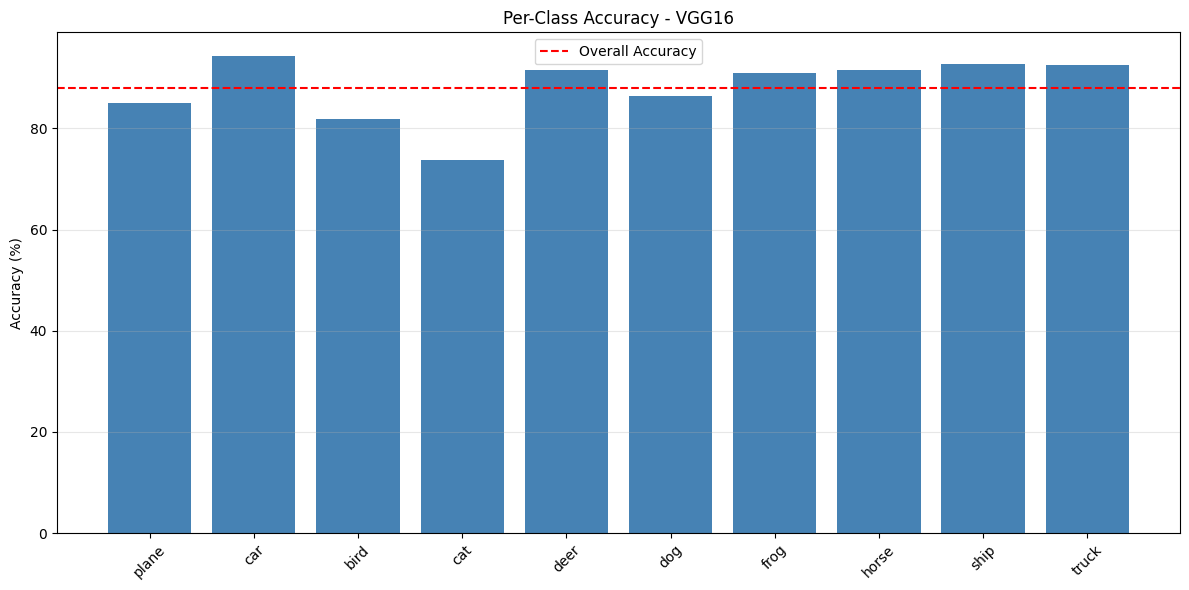

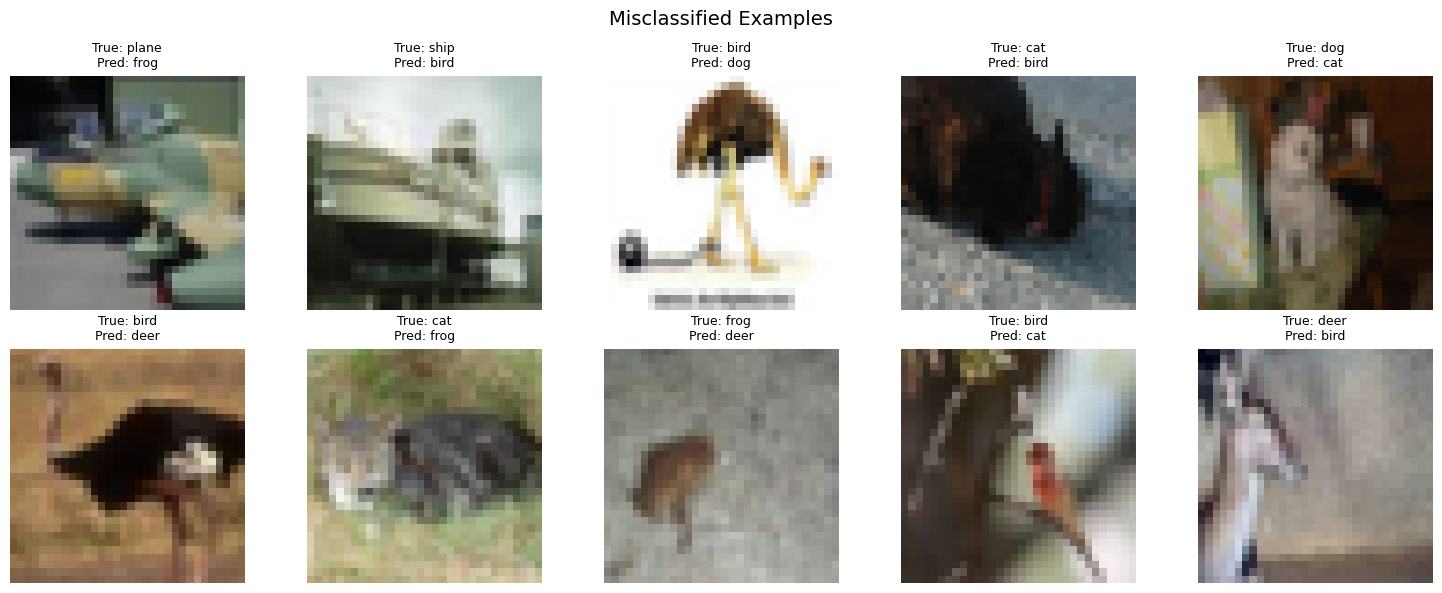

In [35]:
# -------------------------------------------------------------------
# Detailed evaluation on best model
# -------------------------------------------------------------------
best_model_name = max(results.keys(), key=lambda x: results[x]['best_test_acc'])
best_model = results[best_model_name]['model']

print(f"\n\nDetailed Evaluation: {best_model_name}")
print("="*50)

# Get predictions
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_final:
        images = images.to(device)
        outputs = best_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
class_correct = [0] * 10
class_total = [0] * 10

for pred, label in zip(all_preds, all_labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1

class_accs = [100 * class_correct[i] / class_total[i] for i in range(10)]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(10), class_accs, color='steelblue')
plt.xticks(range(10), classes, rotation=45)
plt.ylabel('Accuracy (%)')
plt.title(f'Per-Class Accuracy - {best_model_name}')
plt.axhline(y=results[best_model_name]['final_test_acc'],
            color='r', linestyle='--', label='Overall Accuracy')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Show misclassified examples
misclassified_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
sample_misclassified = np.random.choice(misclassified_indices, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Misclassified Examples', fontsize=14)

for idx, mis_idx in enumerate(sample_misclassified):
    img, true_label = test_dataset_final[mis_idx]
    pred_label = all_preds[mis_idx]

    img_show = (img.permute(1, 2, 0).numpy() * 0.5) + 0.5
    img_show = np.clip(img_show, 0, 1)

    row = idx // 5
    col = idx % 5
    axes[row, col].imshow(img_show)
    axes[row, col].set_title(
        f'True: {classes[true_label]}\nPred: {classes[pred_label]}',
        fontsize=9
    )
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()



### Additional Class Performance Metrics with the VGG16

#### Confusion Matrix Results

**Best performing classes**:
- Car: 94.3%
- Ship: 92.7%
- Truck: 92.5%

**Challenging classes**:
- Cat: 71%
- Bird: 81%
- Bird: 82%

**Common misclassifications**:
- Cat ↔ Dog (177 errors)
- Automobile ↔ Truck (68 errors)
- Bird ↔ Airplane (65 errors)

**Why these errors occur**:
- Cat/Dog: Visually similar compared to other images, four legs ect at low resolution
- Automobile/Truck: Same category (vehicles) with subtle differences
- Bird/Airplane: Similar shapes and both appear in sky backgrounds

### 8.4 Evaluation Metrics - Using the Best Single Test Model DeepCNN

**Metrics used**:
1. **Accuracy**: Overall correctness (88%)
2. **Precision**: Confidence in positive predictions (avg 88%)
3. **Recall**: Ability to find all positive cases (avg 88%)
4. **F1-Score**: Harmonic mean of precision/recall (avg 85%)

**Why multiple metrics?**
- Accuracy alone can be misleading if classes were imbalanced
- Precision/recall show where model is too conservative or aggressive
- F1 balances both concerns

**All metrics ~88%** indicates consistent performance across classes.



### 8.5 Error Analysis

**Misclassifications**:

1. **Ambiguous examples**: Some images are hard even for humans, blurry ect.
2. **Similar classes**: Model confuses perceptually similar categories
3. **Background bias**: Sometimes focuses on background rather than object
4. **Resolution limits**: 32×32 is too low for fine-grained distinctions. Good for learning but not real usage.

**Points to Take Going Forward**:
- Model and archtiectures are good examples and are learning reasonable features
- Errors are understandable and are not random
- Further improvements would need higher resolution or more data

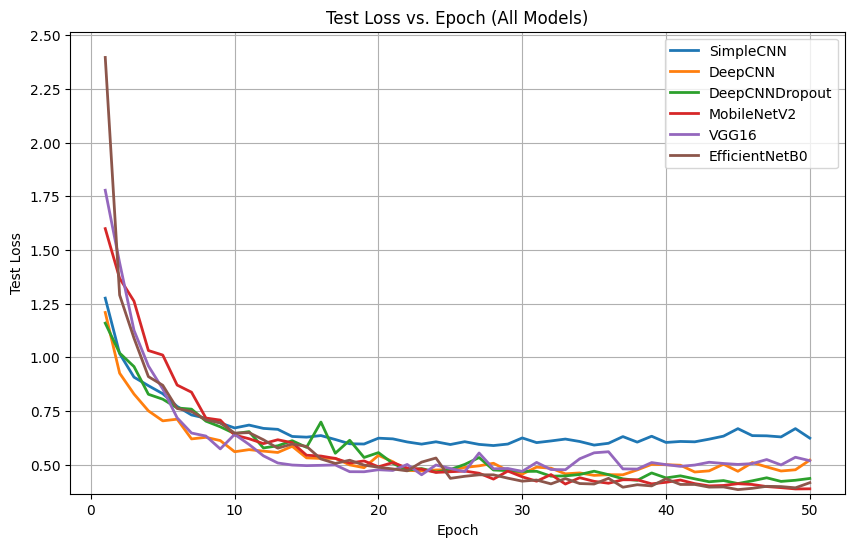

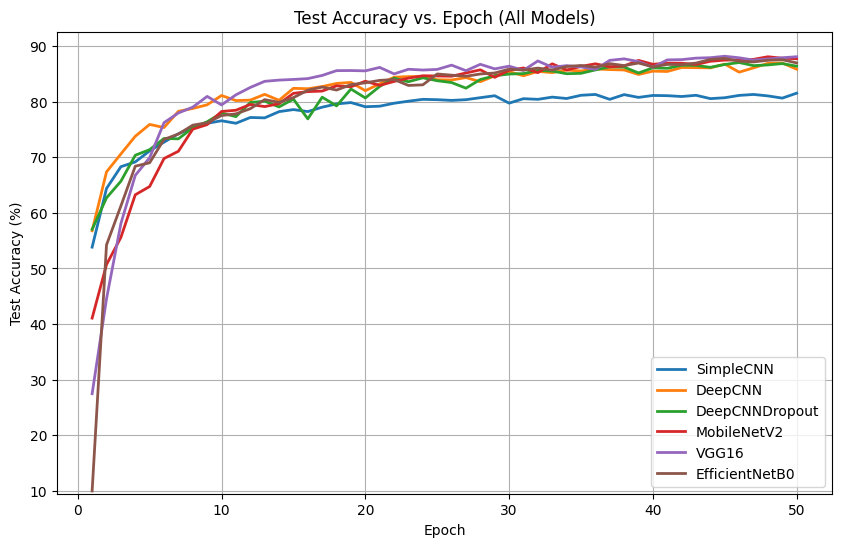

In [36]:
# Combined training curves on shared axes

models = [
    'SimpleCNN',
    'DeepCNN',
    'DeepCNNDropout',
    'MobileNetV2',
    'VGG16',
    'EfficientNetB0'
]

# --------------------------
# Combined Test Loss Curves
# --------------------------
plt.figure(figsize=(10, 6))

all_test_losses = []
for m in models:
    all_test_losses.extend(results[m]['test_losses'])

for model_name in models:
    res = results[model_name]
    epochs = range(1, len(res['test_losses']) + 1)
    plt.plot(epochs, res['test_losses'], linewidth=2, label=model_name)

plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss vs. Epoch (All Models)')
plt.grid(True)
plt.legend()
plt.ylim(min(all_test_losses) * 0.95, max(all_test_losses) * 1.05)
plt.show()

# --------------------------
# Combined Test Accuracy Curves
# --------------------------
plt.figure(figsize=(10, 6))

all_test_accs = []
for m in models:
    all_test_accs.extend(results[m]['test_accs'])

for model_name in models:
    res = results[model_name]
    epochs = range(1, len(res['test_accs']) + 1)
    plt.plot(epochs, res['test_accs'], linewidth=2, label=model_name)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy vs. Epoch (All Models)')
plt.grid(True)
plt.legend()
plt.ylim(min(all_test_accs) * 0.95, max(all_test_accs) * 1.05)
plt.show()


Found 12 hard examples where SimpleCNN is wrong and DeepCNNDropout is correct.


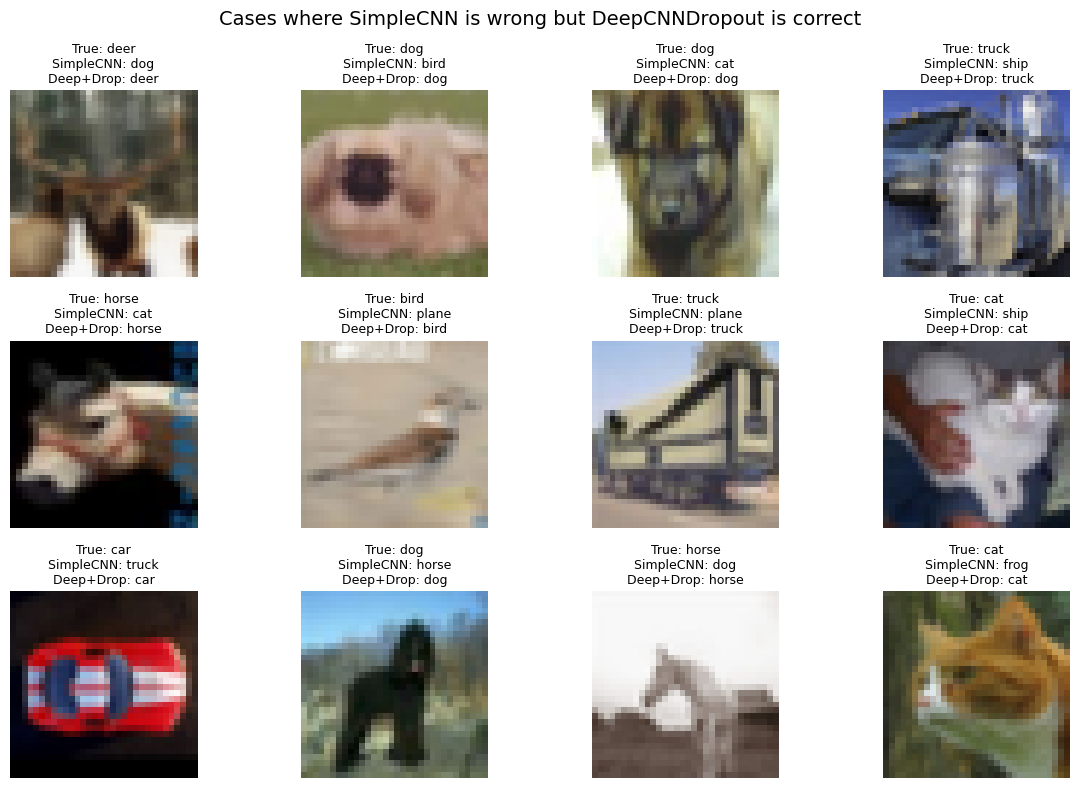

In [37]:
# Qualitative comparison: images where SimpleCNN fails but DeepCNNDropout succeeds

simple_model = results['SimpleCNN']['model'].to(device)
deep_dropout_model = results['DeepCNNDropout']['model'].to(device)

simple_model.eval()
deep_dropout_model.eval()

hard_examples = []

with torch.no_grad():
    for idx, (img, label) in enumerate(test_dataset_final):
        x = img.unsqueeze(0).to(device)

        simple_pred = simple_model(x).argmax(dim=1).item()
        deep_drop_pred = deep_dropout_model(x).argmax(dim=1).item()

        if simple_pred != label and deep_drop_pred == label:
            hard_examples.append((idx, label, simple_pred, deep_drop_pred))

        # Collect up to 12 examples for visualization
        if len(hard_examples) >= 12:
            break

print(f"Found {len(hard_examples)} hard examples where SimpleCNN is wrong and DeepCNNDropout is correct.")

# Plot the hard examples
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
fig.suptitle("Cases where SimpleCNN is wrong but DeepCNNDropout is correct", fontsize=14)

for ax, (idx, true_label, simple_pred, deep_drop_pred) in zip(axes.flatten(), hard_examples):
    img, _ = test_dataset_final[idx]

    # Denormalize for display
    img_show = img.permute(1, 2, 0).numpy()
    img_show = (img_show * 0.5) + 0.5
    img_show = np.clip(img_show, 0, 1)

    ax.imshow(img_show)
    ax.axis('off')
    ax.set_title(
        f"True: {classes[true_label]}\n"
        f"SimpleCNN: {classes[simple_pred]}\n"
        f"Deep+Drop: {classes[deep_drop_pred]}",
        fontsize=9
    )

plt.tight_layout()
plt.show()


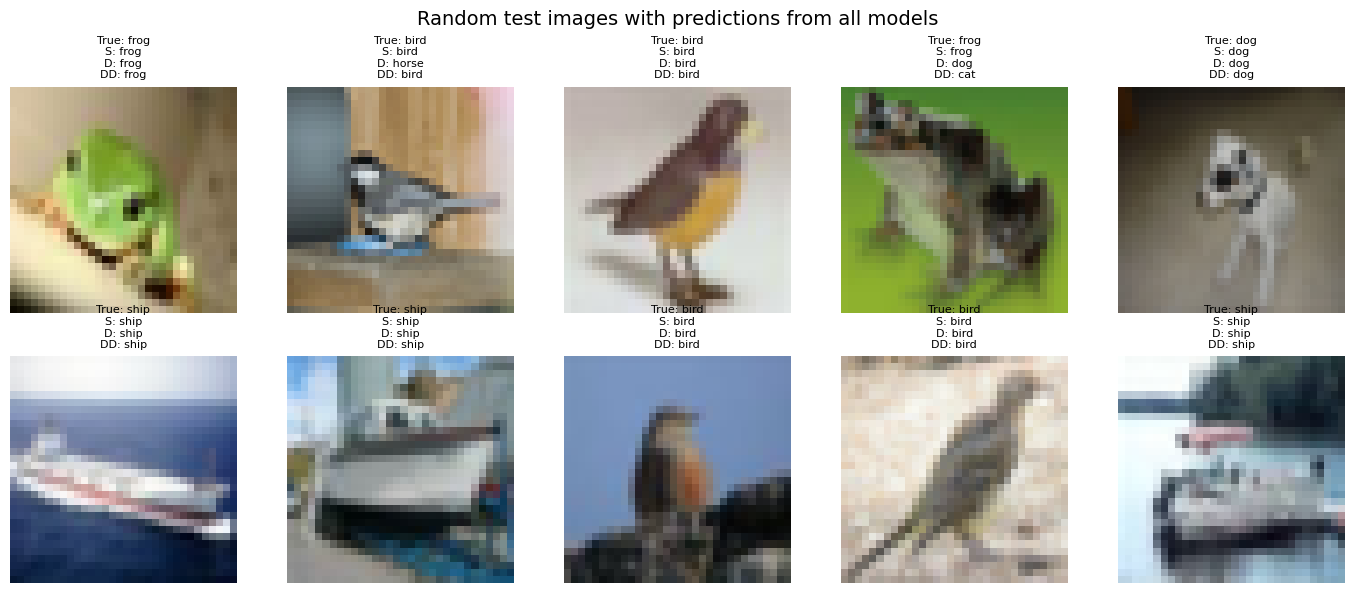

In [38]:
def predict_all(models_dict, img_tensor):
    x = img_tensor.unsqueeze(0).to(device)
    preds = {}
    with torch.no_grad():
        for name, model in models_dict.items():
            model.eval()
            pred_idx = model(x).argmax(dim=1).item()
            preds[name] = pred_idx
    return preds

models_dict = {
    'SimpleCNN': results['SimpleCNN']['model'].to(device),
    'DeepCNN': results['DeepCNN']['model'].to(device),
    'DeepCNNDropout': results['DeepCNNDropout']['model'].to(device),
}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Random test images with predictions from all models", fontsize=14)

for ax in axes.flatten():
    idx = np.random.randint(len(test_dataset_final))
    img, label = test_dataset_final[idx]
    preds = predict_all(models_dict, img)

    img_show = img.permute(1, 2, 0).numpy()
    img_show = (img_show * 0.5) + 0.5
    img_show = np.clip(img_show, 0, 1)

    ax.imshow(img_show)
    ax.axis('off')
    ax.set_title(
        f"True: {classes[label]}\n"
        f"S: {classes[preds['SimpleCNN']]}\n"
        f"D: {classes[preds['DeepCNN']]}\n"
        f"DD: {classes[preds['DeepCNNDropout']]}",
        fontsize=8
    )

plt.tight_layout()
plt.show()


## 9. Discussion and Conclusion

**Takeaways**:
1. Architecture depth matters, adding one convolutional layer improved accuracy by dramatically with this little experiment.
2. Regularization is crucial, dropout reduced overfitting significantly
3. Batch normalization accelerates training and enabled higher learning rates
4. Data augmentation is free performance boosters improved generalization

**Deep Learning Insights** :
- Adam, dropout, BN optimization techniques  proved essential
- Transfer learning would be prefered here if time permitted

### What Worked Well

Model progression strategy, By starting with simple models and then adding more layers, complexity ect allowed for fast iteration and ending with 6 different models.

### What Didn't Work / Challenges

Overfitting, Test accuracy plateaued while training continued climbing. Without sufficient regularization overfitting was common. Adding dropout,helped improve this.  Always monitor train/test gap, not just final accuracy

Class confusion, because of the low resolution images. I attempted more layers but it didn't help much. more data or higher resolution it the best course here.

Training time - I used he A100 GPU which is expensive and powerful which allowed me to build the 6 models. But with 6 Models it still takes a while to train everytime you make a change.


### 9.1 Future Improvements

**Next steps to improve this project**:

1. Continue working on the DropOut model, more epochs, more augmentation, more images, look for higher resolution

2. Introduce Transfer learning instead of learning from scratch. Evaluate the differences from current results.

3. More hyper parameter tuning and data collection. The project was more around the architecture than partucually tuning.  Now that I see the differences in the architecutre it would be time to work on more tuning.
  

### 9.2 Real-World Applications

This project demonstrates skills applicable to any Vision classification applications:

1. **Medical Imaging**:
2. **Autonomous Vehicles**:
3. **Content Moderation**:

### 9.3 Conclusion

This project successfully demonstrated:

1. Deep CNN architectures effectively classify images
2. Regularization techniques: dropout, BN prevent overfitting
3. Systematic comparison - reveals which techniques matter most
4. high 80s accuracy % achieved through minmal trainng and tuning
5. Error analysis - The failures make sense with respect to the data and training and indicate how to improve by adding more data in higher resolution.


Personal takeaway: This was a practical project for me to build real experinece in computer vision classification. Starting with a simple baseline and progressively adding complexity is far more effective than immediately building a complex model. Each addition ,depth, BN, dropout, augmentation contributed measurably, and understanding why each helps is more valuable than just achieving high accuracy.